# ADB: AI for Safer Roads Innovation Challenge
## Data Exploration Notebook

In [1]:
# load libraries
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

### GeoJSON Files

In [4]:
# Load the files
ind_gdf = gpd.read_file("../adb_data/ADB_Innovation_Maharashtra.geojson")
thai_gdf = gpd.read_file("../adb_data/ADB_Innovation_Thailand.geojson")

In [14]:
def geo_eda_compare(gdf1, name1, gdf2, name2):
    df1 = pd.DataFrame({'column': gdf1.columns, 'dtype': gdf1.dtypes.values})
    df2 = pd.DataFrame({'column': gdf2.columns, 'dtype': gdf2.dtypes.values})
    
    comparison = df1.merge(df2, on='column', how='outer', suffixes=(f'_{name1}', f'_{name2}'))
    
    print(f"{name1} shape: {gdf1.shape} | {name2} shape: {gdf2.shape}")
    display(comparison)

geo_eda_compare(thai_gdf, 'Thailand', ind_gdf, 'Maharashtra')


Thailand shape: (55884, 27) | Maharashtra shape: (14082, 28)


,column,dtype_Thailand,dtype_Maharashtra
0,AnalysisStatus,str,str
1,DISSOLVE_ID,NaN,str
2,ExcludeFromSpeedSPI,NaN,float64
3,F85thPercentileSpeed,float64,float64
4,ForAnalysis,float64,NaN
5,InvPercentile,float64,NaN
6,LandUse,str,str
7,MedianSpeed,float64,float64
8,NO_OF_Result_Segments,float64,NaN
9,NumberOverLimit,float64,float64


In [37]:
# ── MISSINGNESS ──────────────────────────────────────────────────
print("=== THAILAND — Null counts ===")
print(thai_gdf.isnull().sum())
thai_gdf.head()


=== THAILAND — Null counts ===
OBJECTID                     0
english_ro                   0
OvertureID                   0
SampleSize_avg           44340
RoadLength                   0
WeightedSample           44340
Percent_                 44340
Percentile               44340
SpeedLimit               44288
RoadClass                    0
NumberOverLimit          44340
MedianSpeed              44340
F85thPercentileSpeed     44340
ForAnalysis              44340
ProvinceID                   0
SpeedLimitFloor          44288
PercentOverLimit         44340
InvPercentile            44340
AnalysisStatus               0
RankedPercentile         44340
StreetImageLink              0
LandUse                  44287
NO_OF_Result_Segments    44340
PercentileBand           44340
SampleSizeTotal          44340
Shape_Length                 0
geometry                     0
dtype: int64


,OBJECTID,english_ro,OvertureID,SampleSize_avg,RoadLength,WeightedSample,Percent_,Percentile,SpeedLimit,RoadClass,...,InvPercentile,AnalysisStatus,RankedPercentile,StreetImageLink,LandUse,NO_OF_Result_Segments,PercentileBand,SampleSizeTotal,Shape_Length,geometry
0,1,Surin Ring Road,1,NaN,4.632086,NaN,NaN,NaN,NaN,primary,...,NaN,Not Included,NaN,"103.4699393,14.839138,103.43891053,14.86699584",NaN,NaN,NaN,NaN,4632.086492,"LINESTRING (103.46994 14.83914, 103.46967 14.8..."
1,2,Surin Ring Road,2,44479.6,2.300000,102303.08,0.000002,0.002591,66.0,primary,...,0.997409,Valid,26.253458,"103.43891053,14.86699584,103.48332214,14.94166589",RURAL,1.0,0-5%,222398.0,11672.918346,"LINESTRING (103.43891 14.867, 103.4383 14.8677..."
2,3,Surin Ring Road,3,NaN,0.122010,NaN,NaN,NaN,NaN,primary,...,NaN,Not Included,NaN,"103.48332214,14.94166589,103.48440114,14.94199564",NaN,NaN,NaN,NaN,122.010111,"LINESTRING (103.48332 14.94167, 103.48405 14.9..."
3,4,Surin Ring Road,4,NaN,2.045467,NaN,NaN,NaN,NaN,primary,...,NaN,Not Included,NaN,"103.48440114,14.94199564,103.50325276,14.94199566",NaN,NaN,NaN,NaN,2045.467119,"LINESTRING (103.4844 14.942, 103.4846 14.94205..."
4,5,Surin Ring Road,5,NaN,2.028143,NaN,NaN,NaN,NaN,primary,...,NaN,Not Included,NaN,"103.50325276,14.94199566,103.5216215,14.9380875",NaN,NaN,NaN,NaN,2028.142985,"LINESTRING (103.50325 14.942, 103.5072 14.9411..."


In [ ]:
# Filter the data based on Analysis Status Column
thai_sub_gdf = thai_gdf[thai_gdf['AnalysisStatus'] == "Valid"]

# Remove unnecessary columns
thai_sub_gdf = thai_sub_gdf.drop(columns=['RoadLength', 'Percent_', 'ForAnalysis',
                                      'SpeedLimitFloor','NO_OF_Result_Segments', 'AnalysisStatus', 'InvPercentile'])

In [33]:
thai_sub_gdf.shape
print(f"Does the subset have any null fields? {thai_sub_gdf.isnull().any().any()}")

thai_sub_gdf.columns

Does the subset have any null fields? False


Index(['OBJECTID', 'english_ro', 'OvertureID', 'SampleSize_avg',
       'WeightedSample', 'Percentile', 'SpeedLimit', 'RoadClass',
       'NumberOverLimit', 'MedianSpeed', 'F85thPercentileSpeed', 'ProvinceID',
       'PercentOverLimit', 'InvPercentile', 'RankedPercentile',
       'StreetImageLink', 'LandUse', 'PercentileBand', 'SampleSizeTotal',
       'Shape_Length', 'geometry'],
      dtype='str')

In [35]:
# Get a feel for the distributions of the key numeric columns

"""
Column Description
    SampleSize_avg:        Average number of GPS probe observations across collection periods
    WeightedSample:        Traffic volume proxy (sample size scaled by road length)
    Percentile:            Which traffic volume percentile this road falls into (0–1 scale)
    SpeedLimit:            Posted speed limit from TomTom — not independently validated
    RoadClass:             Functional road type — motorway, trunk, primary, or secondary
    NumberOverLimit:       Estimated number of vehicles per year exceeding the speed limit
    MedianSpeed:           50th percentile of observed vehicle speeds
    F85thPercentileSpeed:  Speed below which 85% of vehicles travel — the traffic engineering standard
"""

# Which columns matter the most? Undecided
speed_cols = ['WeightedSample', 'Percentile', 'SpeedLimit', 'RoadClass','NumberOverLimit',
              'MedianSpeed', 'F85thPercentileSpeed', 'PercentOverLimit', 'RankedPercentile',
              'PercentileBand', 'SampleSizeTotal']

# Create a summary statistics table
rows = []
for col in speed_cols:
    if thai_sub_gdf[col].dtype in ['float64', 'int64']:
        rows.append({
            'column': col,
            'min': thai_sub_gdf[col].min(),
            'max': thai_sub_gdf[col].max(),
            'mean': thai_sub_gdf[col].mean().round(2),
            'range': thai_sub_gdf[col].max() - thai_sub_gdf[col].min()
        })

summary_df = pd.DataFrame(rows)
display(summary_df)


,column,min,max,mean,range
0,WeightedSample,0.000000,1.551703e+09,4538416.07,1.551703e+09
1,Percentile,0.000000,1.000000e+00,0.04,1.000000e+00
2,SpeedLimit,0.000000,1.200000e+02,80.55,1.200000e+02
3,NumberOverLimit,0.000000,5.893935e+07,211431.05,5.893935e+07
4,MedianSpeed,0.000000,1.300000e+02,64.54,1.300000e+02
5,F85thPercentileSpeed,0.000000,1.500000e+02,78.28,1.500000e+02
6,PercentOverLimit,0.000000,1.000000e+00,0.22,1.000000e+00
7,RankedPercentile,0.008645,9.979253e+01,49.90,9.978389e+01
8,SampleSizeTotal,8.000000,9.031018e+07,762447.35,9.031018e+07


In [ ]:
# categorical columns: RoadClass, LandUse
# get the count of categories in each cols and their values

In [ ]:
# map some of them on the map using a categorical column

# focus on one country now based on the completness of the data maybe or availibility of other data

# Use WeightedSample to prioritize which roads matter
# Use SampleSizeTotal to validate whether to trust the speed data on a given segment

<Axes: >

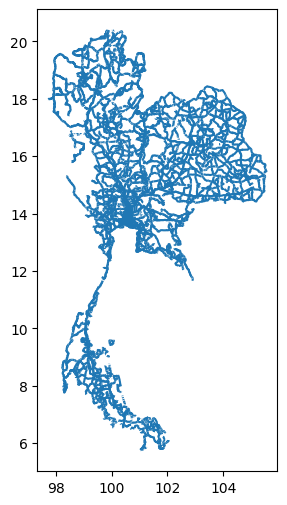

In [38]:
# Check the geometry
# check coordinate reference system (CRS)

# display the road network of Thailand
thai_sub_gdf.plot(figsize=(10,6))

<Axes: >

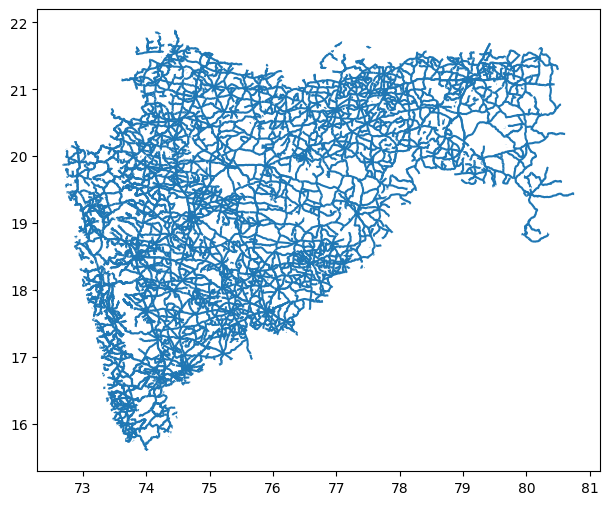

In [14]:
# display the road network of India
ind_gdf.plot(figsize=(10,6))

In [9]:
# Remove the geometry data and get the features only for processing
ind_df = pd.DataFrame(thai_gdf.drop(columns='geometry'))
thai_df = pd.DataFrame(ind_gdf.drop(columns='geometry'))

In [15]:
# Create a summary table based on the required fields


### GPKG Files

In [36]:
thai_gpkg = gpd.read_file("../adb_data/Archive/Road_Safety_Performance_Indicators__Thailand_(Feature).gpkg")

/Users/tasnimahmed/GitHub/RoadPulse/.venv/lib/python3.11/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'Road_Safety_Performance_Indicators__Thailand_(Feature).gpkg': 'ADB_Results_D4' (default), 'Thailand_Province_Boundaries', 'Analysis', 'AnalysisAggregated', 'AggregatedPercentiles'. Specify layer parameter to avoid this warning.
  result = read_func(
